# Q* Learning with Taxi 🚕

In this Notebook we implement a tabular **Q-learning** agent that learns to play the **Taxi** game.

The job of the taxi is simple: **drive to the passenger, pick them up, drive to their destination, and drop them off.**

This follows the exact same recipe as the *FrozenLake* notebook (the professor's reference),
adapted to the [Taxi environment](https://gymnasium.farama.org/environments/toy_text/taxi/).

**The environment (Taxi-v3 / v4):**
- **500 states** = 25 taxi positions × 5 passenger locations (4 pickup spots + *in the taxi*) × 4 destinations.
- **6 actions**: `0` = South ↓, `1` = North ↑, `2` = East →, `3` = West ←, `4` = Pickup, `5` = Drop-off.
- **Rewards**: `-1` per step (so the agent learns to be fast), `+20` for a correct drop-off,
  `-10` for an illegal pickup / drop-off. Episodes are cut off after 200 steps.

Unlike FrozenLake, Taxi is **deterministic** (no slippery ice), so learning is reliable —
but with 500 states it needs more episodes to fill the Q-table.

## Step -1: Install the dependencies on Google Colab

In [1]:
# gymnasium provides the Taxi environment.
# The [toy-text] extra installs pygame, which is only needed for the OPTIONAL graphical replay at the end.
!pip install "gymnasium[toy-text]" > /dev/null 2>&1

## Step 0: Import the dependencies 📚
- `Numpy` for our Q-table
- `Gymnasium` for the Taxi environment
- `random` to generate random numbers (for exploration)
- `matplotlib` to plot the learning curve

In [2]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

## Step 1: Create the environment 🎮
Newer versions of Gymnasium renamed `Taxi-v3` to `Taxi-v4` (same game, same rewards).
The helper below just grabs whichever one your installed version provides, so this notebook
works **both locally and on Colab** regardless of the gymnasium version.

In [3]:
def make_taxi(render_mode=None):
    """Create the Taxi environment, working across gymnasium versions (v3 -> v4)."""
    last_error = None
    for version in ("Taxi-v3", "Taxi-v4"):
        try:
            return gym.make(version, render_mode=render_mode)
        except Exception as e:   # e.g. DeprecatedEnv / version not found on this gymnasium
            last_error = e
    raise last_error

env = make_taxi()
print("Using:", env.spec.id)

Using: Taxi-v4


/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment Taxi-v3 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


## Step 2: Create the Q-table and initialize it 🗄️
The Q-table has one **row per state** and one **column per action**.
We read those sizes straight from the environment and start every value at 0.

In [4]:
action_size = env.action_space.n
state_size = env.observation_space.n
print(f"Action space is {action_size}; State space is {state_size}\n")

qtable = np.zeros((state_size, action_size))
print("Q-table shape:", qtable.shape)

Action space is 6; State space is 500

Q-table shape: (500, 6)


## Step 3: Create the hyperparameters ⚙️
Same knobs as FrozenLake. Taxi has many more states, so we train for more episodes and let
exploration (`epsilon`) decay slowly from 1.0 down to 0.01.

In [5]:
total_episodes = 25000        # Total training episodes
learning_rate = 0.7           # Learning rate (alpha)
max_steps = 200               # Max steps per episode (Taxi cuts off at 200 anyway)
gamma = 0.95                  # Discounting rate (how much we value future reward)

# Exploration parameters
epsilon = 1.0                 # Exploration rate
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability
decay_rate = 0.0005           # Exponential decay rate for exploration prob

## Step 4: The Q-learning algorithm 🧠
For every episode we play the game; at each step we either **explore** (random action) or
**exploit** (best known action), then nudge `Q(s,a)` toward the reward we just got plus the best
value reachable next:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\max_{a'}Q(s',a') - Q(s,a)\,]$$

Average reward over all episodes: -9.92296
Average reward over last 1000 episodes: 7.394


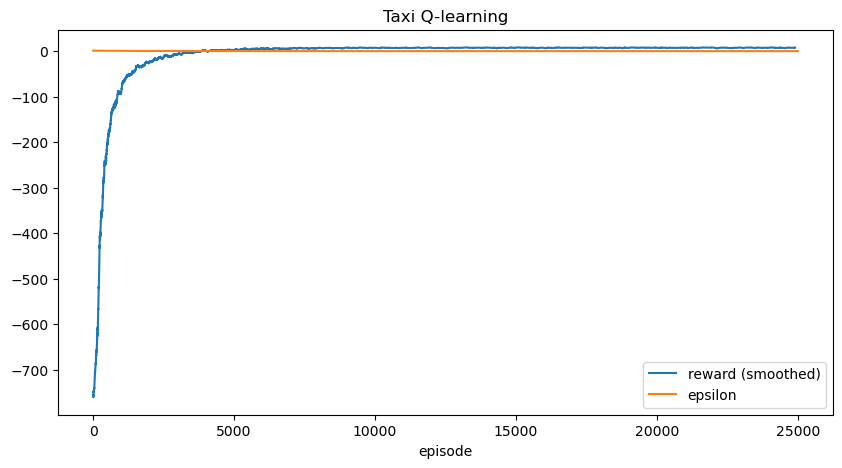

In [6]:
# List of rewards (and epsilons) so we can plot the learning curve
rewards = []
epsilons = []

for episode in range(total_episodes):
    # Reset the environment - Gymnasium returns (state, info)
    state, info = env.reset()
    total_rewards = 0

    for step in range(max_steps):
        # Choose an action: explore (random) or exploit (best known)
        exp_exp_tradeoff = random.uniform(0, 1)
        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state, :])      # exploit
        else:
            action = env.action_space.sample()        # explore

        # Take the action - Gymnasium returns 5 values
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Update Q(s, a) with the Bellman correction
        qtable[state, action] = qtable[state, action] + learning_rate * (
            reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action]
        )

        total_rewards += reward
        state = new_state
        if done:
            break

    # Reduce epsilon (less exploration as the agent gets smarter)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    epsilons.append(epsilon)
    rewards.append(total_rewards)

print("Average reward over all episodes: " + str(sum(rewards) / total_episodes))
print("Average reward over last 1000 episodes: " + str(sum(rewards[-1000:]) / 1000))

# Plot the learning curve (smoothed) and epsilon
plt.figure(figsize=(10, 5))
window = 100
smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
plt.plot(range(len(smoothed)), smoothed, label="reward (smoothed)")
plt.plot(range(total_episodes), epsilons, label="epsilon")
plt.xlabel("episode"); plt.legend(loc="lower right")
plt.title("Taxi Q-learning"); plt.show()

## Step 5: Use our Q-table to play Taxi! 👾  (text replay — works everywhere)
Now we stop learning and just follow the best action in each state (`np.argmax`).
This text replay uses gymnasium's `ansi` render mode, which needs **no extra packages**, so it
runs anywhere. Watch the yellow taxi pick up the passenger and drive them to the destination.

In [7]:
import time
from IPython.display import clear_output

action_names = {0: "South ↓", 1: "North ↑", 2: "East →", 3: "West ←", 4: "Pickup", 5: "Drop-off"}

play_env = make_taxi(render_mode="ansi")
state, info = play_env.reset()
print(play_env.render())

total = 0
for step in range(max_steps):
    action = int(np.argmax(qtable[state, :]))
    state, reward, terminated, truncated, info = play_env.step(action)
    total += reward

    time.sleep(0.4)
    clear_output(wait=True)
    print(play_env.render())
    print(f"Step {step + 1} | action: {action_names[action]} | reward: {reward} | total: {total}")

    if terminated:
        print("Passenger delivered! 🏆")
        break
    if truncated:
        print("Ran out of time ⏰")
        break
play_env.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Step 12 | action: Drop-off | reward: 20 | total: 9
Passenger delivered! 🏆


## Step 5b (optional): Graphical replay 🎬
A nicer animated render using the graphical frames. It needs `pygame` (from
`gymnasium[toy-text]`, installed in Step -1) and builds an inline animation with matplotlib —
**no ffmpeg or xvfb required**, so it works on Colab. If anything is missing it falls back
gracefully and you can still use the text replay above.

In [8]:
try:
    import matplotlib.pyplot as plt
    from matplotlib import animation
    from IPython.display import HTML

    vid_env = make_taxi(render_mode="rgb_array")
    state, info = vid_env.reset()
    frames = [vid_env.render()]
    for step in range(max_steps):
        action = int(np.argmax(qtable[state, :]))
        state, reward, terminated, truncated, info = vid_env.step(action)
        frames.append(vid_env.render())
        if terminated or truncated:
            break
    vid_env.close()

    fig = plt.figure(figsize=(5, 4)); plt.axis("off")
    img = plt.imshow(frames[0])
    def _update(i):
        img.set_data(frames[i]); return [img]
    ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=400, blit=True)
    plt.close(fig)
    display(HTML(ani.to_jshtml()))
except Exception as e:
    print("Graphical replay unavailable (needs gymnasium[toy-text]/pygame). Use the text replay above.")
    print("Reason:", e)

## Step 6: Evaluate the trained agent 📊
One game can get lucky. Let's play 100 games greedily and report the average reward, the average
number of steps, and how often we deliver the passenger successfully. A well-trained Taxi agent
scores around **+8 reward in ~13 steps with a 100% success rate**.

In [9]:
n_eval = 100
ev_rewards, ev_steps, successes = [], [], 0
for _ in range(n_eval):
    state, info = env.reset()
    total = 0
    for step in range(max_steps):
        action = int(np.argmax(qtable[state, :]))
        state, reward, terminated, truncated, info = env.step(action)
        total += reward
        if terminated:
            successes += 1
            break
        if truncated:
            break
    ev_rewards.append(total)
    ev_steps.append(step + 1)

print(f"Over {n_eval} games (greedy / no exploration):")
print(f"  average reward : {np.mean(ev_rewards):.2f}")
print(f"  average steps  : {np.mean(ev_steps):.1f}")
print(f"  success rate   : {successes}/{n_eval}")

Over 100 games (greedy / no exploration):
  average reward : 7.90
  average steps  : 13.1
  success rate   : 100/100
